In [16]:
import pandas as pd
import sagemaker

In [17]:
role = sagemaker.get_execution_role()
print(role)

arn:aws:iam::133080914359:role/service-role/AmazonSageMaker-ExecutionRole-20250813T151499


In [18]:
file_path = "s3://house-price-prediction-cbb/housing.csv"

df = pd.read_csv(file_path)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


In [20]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


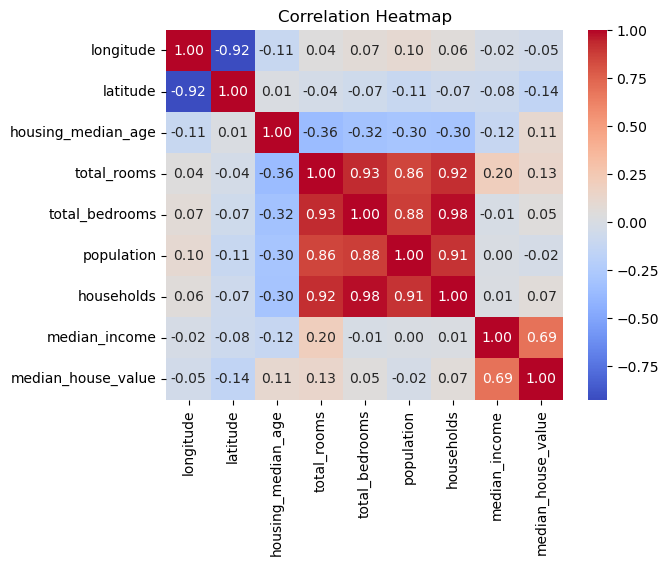

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

##### Observations from the Correlation Plot
1. The target variable is having a good correlation with median_income and as a result, can be used as a feature to make predictions
2. Four features - total rooms, total bedrooms, population and households seems to have a very high correlation among themselve leading to multicollinearity issues. These features need to be combined into a feature before they can be used in the prediction model
3. Latitude and Longitude also do not have a very strong correlation with the target variable

##### Feature Importance Plot

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_fi = df.drop('median_house_value', axis=1)
y_fi = df['median_house_value']

In [23]:
X_fi_train, X_fi_test, y_fi_train, y_fi_test = train_test_split(X_fi, y_fi, test_size=0.25, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_fi_train, y_fi_train)

RandomForestRegressor(random_state=42)

/tmp/ipykernel_162/3958676764.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


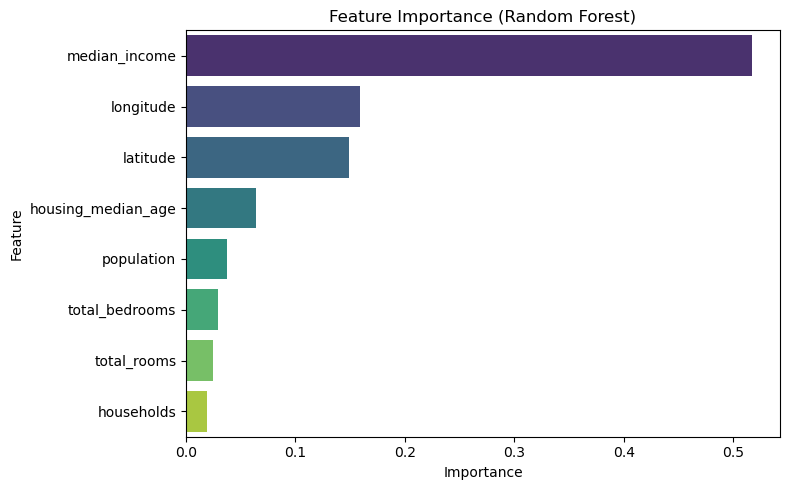

In [24]:
# Get feature importances
importances = rf.feature_importances_
feature_names = X_fi.columns

# Create a DataFrame for plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

##### Statistical Plots

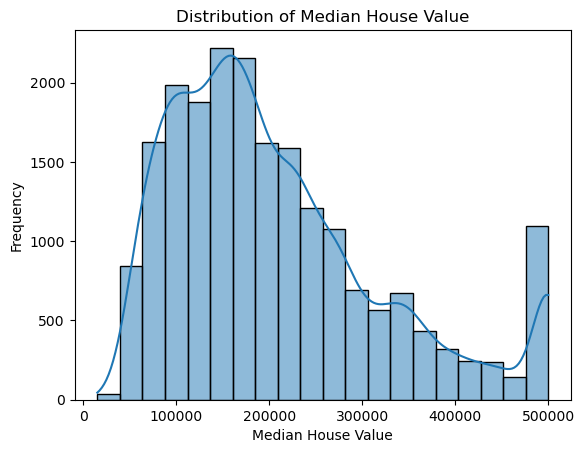

In [25]:
sns.histplot(df['median_house_value'], bins=20, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

Box Plot for Median Income and Median House Value

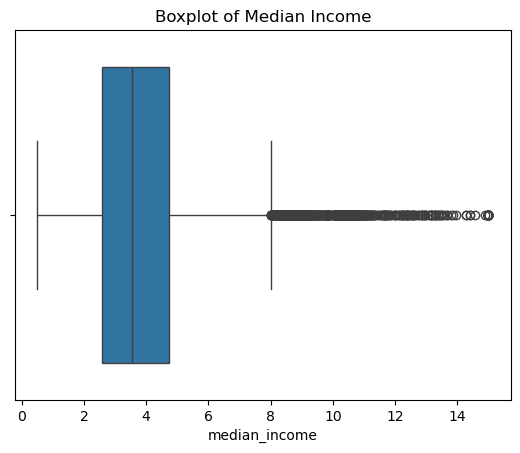

In [26]:
sns.boxplot(x=df['median_income'])
plt.title('Boxplot of Median Income')
plt.show()

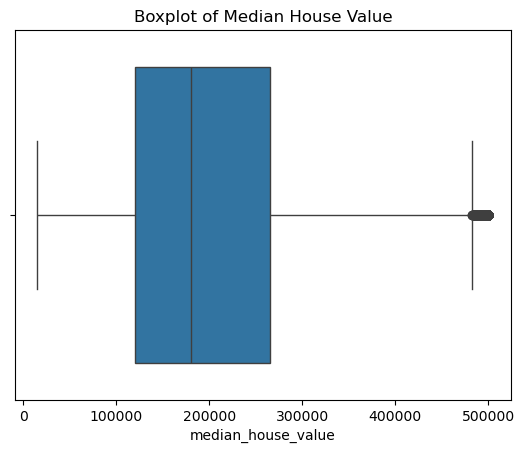

In [27]:
sns.boxplot(x=df['median_house_value'])
plt.title('Boxplot of Median House Value')
plt.show()

Replacing the features which are highly correlated against each other with calculated values based on the features

In [28]:
# People per household
df['population_per_household'] = df['population'] / df['households']

# Rooms per household
df['rooms_per_household'] = df['total_rooms'] / df['households']

# Bedrooms per room
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

In [29]:
df.drop(['total_rooms', 'total_bedrooms', 'population', 'households'],axis=1, inplace=True)

Using KMean clustering to group the data based on combining latitude and longitude

In [30]:
from sklearn.cluster import KMeans

loc = df[['latitude', 'longitude']]

kmeans = KMeans(n_clusters=5, random_state=42)
df['loc_cluster'] = kmeans.fit_predict(loc)



In [31]:
df['loc_cluster'].value_counts()

loc_cluster
0    11027
1     4829
4     2325
2     1771
3      688
Name: count, dtype: int64

In [32]:
### Removing the latitude and longitude features from the dataset and removing the rows with null values
df.drop(['longitude','latitude'], axis=1, inplace=True)
df.dropna(inplace=True)

Applying the standard scaler to the features in the dataset before training the linear regression model against the dataset

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features of the dataset
scaler = StandardScaler()


In [38]:
# Scale features and convert back to DataFrame
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), 
                              columns=X_train.columns, 
                              index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), 
                             columns=X_test.columns, 
                             index=X_test.index)

In [39]:
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((16346, 6), (4087, 6), (16346,), (4087,))

##### Linear Regression Model

Trying the different feature subsets and training the model to check the model performance against different subsets

In [40]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

feature_1 = ["housing_median_age", "median_income"]
feature_2 = ["housing_median_age", "median_income", "population_per_household","rooms_per_household", "bedrooms_per_room"]
feature_3 = ["housing_median_age", "median_income", "loc_cluster"]

# Defining feature subsets for comparing the models
feature_subsets = [
    feature_1,
    feature_2,
    feature_3,
    X.columns.to_list()
]

lr_model = LinearRegression()

results = []

for features in feature_subsets:
    lr_model.fit(X_train_scaled[features], y_train)
    y_pred = lr_model.predict(X_test_scaled[features])
    results.append({
    "features" : features, 
    "R2" : r2_score(y_test, y_pred), 
    "MAE" : mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,features,R2,MAE
0,"[housing_median_age, median_income]",0.508837,61238.171463
1,"[housing_median_age, median_income, population...",0.544609,57692.158784
2,"[housing_median_age, median_income, loc_cluster]",0.537743,58899.945516
3,"[housing_median_age, median_income, population...",0.559738,56661.636604


##### Random Forest Model

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestRegressor(random_state=42)

### defining the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [45]:
results_rf = []

for features in feature_subsets:
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    grid_search = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid,
        cv=3,
        n_jobs=-1,
        scoring="r2"
    )

    grid_search.fit(X_train_subset, y_train)
    best_model = grid_search.best_estimator_

    y_pred = grid_search.predict(X_test_subset)

    results_rf.append({
        "features": features,
        "Best_Params": grid_search.best_params_,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

pd.set_option("display.max_colwidth", None)

results_rf_df = pd.DataFrame(results_rf)
results_rf_df

,features,Best_Params,R2,MAE
0,"[housing_median_age, median_income]","{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}",0.535130,58431.708000
1,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room]","{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}",0.683287,46710.175132
2,"[housing_median_age, median_income, loc_cluster]","{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}",0.590311,52781.092669
3,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room, loc_cluster]","{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}",0.713343,43243.961350


In [46]:
results_rf_new = []
grid_search = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid,
        cv=3,
        n_jobs=-1,
        scoring="r2"
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_


y_pred = grid_search.predict(X_test)

results_rf_new.append({
        "features": features,
        "Best_Params": grid_search.best_params_,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

pd.set_option("display.max_colwidth", None)

results_rf_df_new = pd.DataFrame(results_rf_new)
results_rf_df_new

,features,Best_Params,R2,MAE
0,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room, loc_cluster]","{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}",0.713343,43243.96135


In [47]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df[['params', 'mean_test_score', 'std_test_score']]


,params,mean_test_score,std_test_score
0,"{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}",0.703186,0.007739
1,"{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}",0.704627,0.007300
2,"{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}",0.704178,0.007940
3,"{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}",0.705483,0.007518
4,"{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}",0.706261,0.007537
5,"{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}",0.707632,0.007466
6,"{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}",0.706704,0.006995
7,"{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}",0.707947,0.007280
8,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}",0.709593,0.006188
9,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}",0.710087,0.006039


In [49]:
from sklearn.ensemble import GradientBoostingRegressor

results_gbr = []
gbr_model = GradientBoostingRegressor(random_state=42)

for features in feature_subsets:
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    gbr_model.fit(X_train_subset, y_train)
    y_pred = gbr_model.predict(X_test_subset)

    results_gbr.append(
        {
            "features": features,
            "r2_score": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred)
        }
    )

results_gbr_df = pd.DataFrame(results_gbr)
results_gbr_df

,features,r2_score,MAE
0,"[housing_median_age, median_income]",0.546207,57819.085613
1,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room]",0.674409,47986.963011
2,"[housing_median_age, median_income, loc_cluster]",0.598767,52434.835065
3,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room, loc_cluster]",0.702598,45012.361246


In [50]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

# Define your hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

results_gbr = []

for features in feature_subsets:
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    gbr_model = GradientBoostingRegressor(random_state=42)

    grid_search = GridSearchCV(
        estimator=gbr_model,
        param_grid=param_grid,
        cv=3,
        n_jobs=-1,
        scoring='r2'
    )

    grid_search.fit(X_train_subset, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_subset)

    results_gbr.append({
        "features": features,
        "Best_Params": grid_search.best_params_,
        "r2_score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_gbr_df = pd.DataFrame(results_gbr)
results_gbr_df

,features,Best_Params,r2_score,MAE
0,"[housing_median_age, median_income]","{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}",0.545616,57888.806269
1,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room]","{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}",0.688708,46461.676110
2,"[housing_median_age, median_income, loc_cluster]","{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}",0.598272,52454.294194
3,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room, loc_cluster]","{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}",0.718573,43106.988476


In [51]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3]
}

results_xgb = []

for features in feature_subsets:
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror', verbosity=0)

    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        cv=3,
        n_jobs=-1,
        scoring='r2'
    )

    grid_search.fit(X_train_subset, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_subset)

    results_xgb.append({
        "features": features,
        "Best_Params": grid_search.best_params_,
        "r2_score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_xgb_df = pd.DataFrame(results_xgb)
results_xgb_df

,features,Best_Params,r2_score,MAE
0,"[housing_median_age, median_income]","{'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100}",0.544744,58147.750000
1,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room]","{'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100}",0.692340,46225.953125
2,"[housing_median_age, median_income, loc_cluster]","{'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200}",0.599635,52350.738281
3,"[housing_median_age, median_income, population_per_household, rooms_per_household, bedrooms_per_room, loc_cluster]","{'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100}",0.716882,43094.101562
